In [2]:
from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [32]:
def runge_func(x):
    return 1 / (1 + 25*x**2)

In [58]:
np.random.seed(2025)

degree = 1

xs = np.random.randn(1000)[:,np.newaxis]

X = PolynomialFeatures(degree, include_bias=False).fit_transform(xs)

ys = runge_func(xs)

X_train, X_test, y_train, y_test = train_test_split(X, ys, train_size=0.8)

scalerx = StandardScaler()
scalerx.fit(X_train)
X_train = scalerx.transform(X_train)
X_test  = scalerx.transform(X_test)

scalery = StandardScaler()
scalery.fit(y_train)
y_train = scalery.transform(y_train)
y_test = scalery.transform(y_test)
y_mean = scalery.mean_
print(y_mean)

[0.22506289]


In [59]:
scheduler = Adam(0.01)
ffnn = NeuralNetwork(degree,1, [100,100], [sigmoid, sigmoid, id_func], 
                    [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                     regularization = "", reg_param=2e-13
                    )

In [63]:
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("BEFORE TRAIN")
old_train = mse(train_pred, y_train)
old_test = mse(test_pred, y_test)
print("train", old_train)
print("test ", old_test)

ffnn.train(X_train, y_train, 8, 100)

train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("AFTER TRAIN")
new_train = mse(train_pred, y_train)
new_test = mse(test_pred, y_test)
print("train", new_train)
print("test ", new_test)
print("DIFF")
print("train", new_train-old_train)
print("test", new_test-old_test)

BEFORE TRAIN
train 0.18851928701087511
test  0.19636957145271364
AFTER TRAIN
train 0.03665039032490609
test  0.038982493253697736
DIFF
train -0.15186889668596903
test -0.1573870781990159


In [64]:
print(ffnn._weights_biases)
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)

[(array([[ 2.01370167,  2.53224111, -3.43136302,  3.1846507 ,  2.93459429,
         1.73470126, -3.82017652, -0.00765974, -2.64813389, -2.00430146,
        -2.80586103, -4.99585842,  4.02127646, -2.025161  ,  1.48817158,
        -2.58688555,  0.21325789,  2.20570456, -0.15486243, -2.89157311,
        -2.910402  , -4.09040804,  0.66251755, -2.39151958,  2.20743728,
         2.77821797, -2.96404559,  2.74877568,  3.19782265, -3.81129477,
        -0.41600617, -3.92540944, -0.20559713, -3.10796324, -4.40150792,
         0.76751289, -4.12246232,  3.53145265,  2.40953266,  2.97797885,
        -2.42715928, -2.33283   , -4.42907323,  2.47792076,  3.09947244,
         0.39161082, -2.45533064, -3.35843306,  4.14374536,  1.43706356,
         4.098068  , -0.66847041, -1.34792353,  2.48461267, -2.97077219,
         3.31541798,  2.67761582, -3.4170383 ,  4.45189986, -2.49743293,
         2.62058192,  0.99495612,  0.88512534,  4.54856196,  2.84425671,
        -2.0974416 , -2.17493507, -0.30721109,  1

In [61]:
#print("ffnn\n", ffnn._weights_biases)
test = ffnn._weights_biases
mse_train = mse(train_pred, y_train)
mse_test = mse(test_pred, y_test)
print("train", mse_train)
print("test ", mse_test)
print(np.max(np.abs(test[0][0])))
"""
test[0] = (np.array([[2, -2]]), np.array([[0], [0]]))
test[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))
print("test\n", test)
print("ffnn\n", ffnn._weights_biases)
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("train", mse(train_pred, y_train))
print("test ", mse(test_pred, y_test))
"""

train 0.18851928701087511
test  0.19636957145271364
3.563438564270846


'\ntest[0] = (np.array([[2, -2]]), np.array([[0], [0]]))\ntest[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))\nprint("test\n", test)\nprint("ffnn\n", ffnn._weights_biases)\ntrain_pred = ffnn.predict(X_train)\ntest_pred = ffnn.predict(X_test)\nprint("train", mse(train_pred, y_train))\nprint("test ", mse(test_pred, y_test))\n'

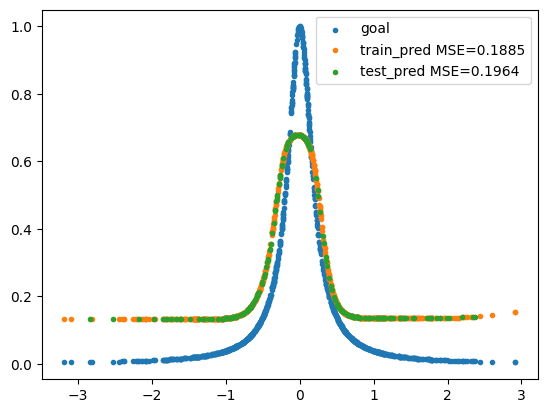

In [62]:
x_test_plot = scalerx.inverse_transform(X_test)[:,0]
y_test_plot = scalery.inverse_transform(test_pred)

x_train_plot = scalerx.inverse_transform(X_train)[:,0]
y_train_plot = scalery.inverse_transform(train_pred)
plt.scatter(xs, ys, marker = ".", label = "goal")
plt.scatter(x_train_plot, y_train_plot, marker=".", label = f"train_pred MSE={mse_train:.4f}")
plt.scatter(x_test_plot, y_test_plot, marker = ".", label = f"test_pred MSE={mse_test:.4f}")
#plt.scatter(X_train_plot, y_train, label = "train")

plt.legend()
plt.show()